In [1]:
import sys
sys.path.append("../src")

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, roc_curve, brier_score_loss, log_loss,
    precision_recall_curve, confusion_matrix,
)
from sklearn.calibration import calibration_curve

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

PROCESSED = Path("../data/processed")
ARTEFACTS = Path("../outputs/models")
FIGURES   = Path("../outputs/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 22

In [2]:
pred = pd.read_parquet(PROCESSED / "holdout_predictions.parquet")

y      = pred["TARGET"]
p_sc   = pred["p_scorecard"]
p_ch   = pred["p_challenger"]

print(f"Holdout rows: {len(pred):,}")
print(f"Bad rate:     {y.mean():.4f}")
print(f"Bads:         {y.sum():,}")
print(f"Goods:        {(1 - y).sum():,}")

Holdout rows: 61,503
Bad rate:     0.0807
Bads:         4,965
Goods:        56,538


In [3]:
def ks_statistic(y_true, y_prob):
    """
    Kolmogorov-Smirnov: maximum separation between the cumulative
    distributions of goods and bads. Standard credit risk metric —
    reports both the KS value and the probability at which it occurs.
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    ks_values = tpr - fpr
    idx = np.argmax(ks_values)
    return ks_values[idx], thresholds[idx], fpr, tpr, thresholds


for name, p in [("Scorecard", p_sc), ("Challenger", p_ch)]:
    ks, ks_thr, *_ = ks_statistic(y, p)
    auc = roc_auc_score(y, p)
    print(f"{name:<12} AUC {auc:.4f}   Gini {2*auc-1:.4f}   "
          f"KS {ks:.4f}   at PD {ks_thr:.4f}")

Scorecard    AUC 0.7424   Gini 0.4848   KS 0.3639   at PD 0.0782
Challenger   AUC 0.7847   Gini 0.5694   KS 0.4365   at PD 0.0665


In [4]:
def score_band_table(y_true, y_prob, n_bands=10, label=""):
    """
    Decile analysis: bad rate, lift, and cumulative capture by score band.
    Band 1 = lowest risk (best scores), Band 10 = highest risk.
    """
    df = pd.DataFrame({"y": y_true.values, "p": y_prob.values})
    df["band"] = pd.qcut(df["p"], q=n_bands, labels=False, duplicates="drop") + 1

    tbl = df.groupby("band").agg(
        n=("y", "size"),
        bads=("y", "sum"),
        min_pd=("p", "min"),
        max_pd=("p", "max"),
        mean_pd=("p", "mean"),
    ).reset_index()

    tbl["bad_rate"]      = tbl["bads"] / tbl["n"]
    tbl["lift"]          = tbl["bad_rate"] / y_true.mean()
    tbl["pct_of_bads"]   = tbl["bads"] / tbl["bads"].sum()
    tbl["cum_pct_bads"]  = tbl["pct_of_bads"][::-1].cumsum()[::-1]
    tbl["cum_pct_pop"]   = tbl["n"][::-1].cumsum()[::-1] / tbl["n"].sum()

    print(f"\n{'='*88}")
    print(f"  {label}")
    print(f"{'='*88}")
    print(tbl[["band", "n", "bads", "mean_pd", "bad_rate", "lift",
               "cum_pct_bads", "cum_pct_pop"]].to_string(index=False))

    # Monotonicity check
    monotonic = tbl["bad_rate"].is_monotonic_increasing
    print(f"\n  Bad rate monotonically increasing: {monotonic}")
    print(f"  Band 10 lift: {tbl['lift'].iloc[-1]:.2f}x   "
          f"Band 1 lift: {tbl['lift'].iloc[0]:.2f}x")
    return tbl


bands_sc = score_band_table(y, p_sc, label="SCORECARD — score bands (deciles)")
bands_ch = score_band_table(y, p_ch, label="CHALLENGER — score bands (deciles)")


  SCORECARD — score bands (deciles)
 band    n  bads  mean_pd  bad_rate   lift  cum_pct_bads  cum_pct_pop
    1 6151    79   0.0139    0.0128 0.1591        1.0000       1.0000
    2 6150   158   0.0224    0.0257 0.3182        0.9841       0.9000
    3 6150   178   0.0300    0.0289 0.3585        0.9523       0.8000
    4 6150   249   0.0385    0.0405 0.5015        0.9164       0.7000
    5 6151   294   0.0484    0.0478 0.5921        0.8663       0.6000
    6 6150   380   0.0608    0.0618 0.7654        0.8070       0.5000
    7 6150   495   0.0779    0.0805 0.9970        0.7305       0.4000
    8 6150   675   0.1029    0.1098 1.3596        0.6308       0.3000
    9 6150   931   0.1444    0.1514 1.8752        0.4949       0.2000
   10 6151  1526   0.2601    0.2481 3.0732        0.3074       0.1000

  Bad rate monotonically increasing: True
  Band 10 lift: 3.07x   Band 1 lift: 0.16x

  CHALLENGER — score bands (deciles)
 band    n  bads  mean_pd  bad_rate   lift  cum_pct_bads  cum_pct_pop

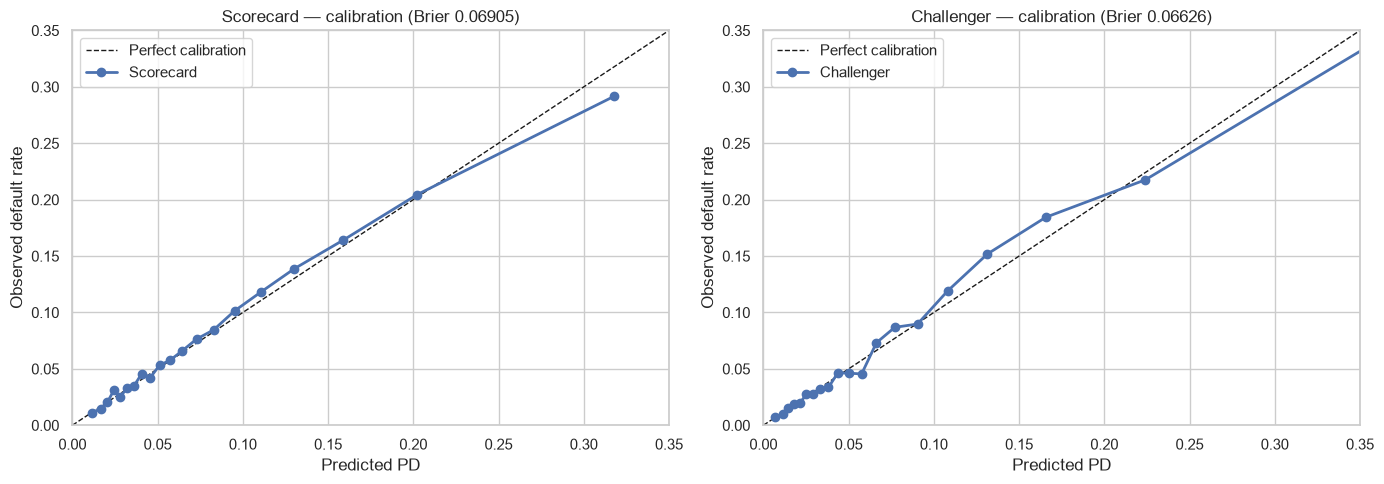


--- SCORECARD ---
 predicted_pd  observed_pd    diff  ratio
       0.0139       0.0128 -0.0011 0.9226
       0.0224       0.0257  0.0033 1.1463
       0.0300       0.0289 -0.0011 0.9644
       0.0385       0.0405  0.0020 1.0525
       0.0484       0.0478 -0.0006 0.9868
       0.0608       0.0618  0.0010 1.0157
       0.0779       0.0805  0.0026 1.0338
       0.1029       0.1098  0.0069 1.0671
       0.1444       0.1514  0.0069 1.0480
       0.2601       0.2481 -0.0120 0.9540
Mean absolute deviation: 0.00375

--- CHALLENGER ---
 predicted_pd  observed_pd    diff  ratio
       0.0091       0.0088 -0.0003 0.9620
       0.0164       0.0174  0.0010 1.0617
       0.0234       0.0237  0.0004 1.0154
       0.0313       0.0301 -0.0012 0.9606
       0.0409       0.0400 -0.0009 0.9777
       0.0538       0.0459 -0.0080 0.8519
       0.0717       0.0800  0.0083 1.1158
       0.0992       0.1044  0.0052 1.0520
       0.1486       0.1681  0.0196 1.1318
       0.3029       0.2889 -0.0140 0.9539
Mean

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, p) in zip(axes, [("Scorecard", p_sc), ("Challenger", p_ch)]):
    prob_true, prob_pred = calibration_curve(y, p, n_bins=20, strategy="quantile")
    ax.plot([0, 0.35], [0, 0.35], "k--", lw=1, label="Perfect calibration")
    ax.plot(prob_pred, prob_true, "o-", lw=2, label=name)
    ax.set_xlabel("Predicted PD")
    ax.set_ylabel("Observed default rate")
    ax.set_title(f"{name} — calibration (Brier {brier_score_loss(y, p):.5f})")
    ax.legend()
    ax.set_xlim(0, 0.35)
    ax.set_ylim(0, 0.35)

plt.tight_layout()
plt.savefig(FIGURES / "calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Numerical calibration table
def calibration_table(y_true, y_prob, name, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy="quantile")
    tbl = pd.DataFrame({
        "predicted_pd": prob_pred,
        "observed_pd": prob_true,
        "diff": prob_true - prob_pred,
        "ratio": prob_true / prob_pred,
    })
    print(f"\n--- {name} ---")
    print(tbl.to_string(index=False))
    print(f"Mean absolute deviation: {tbl['diff'].abs().mean():.5f}")

calibration_table(y, p_sc, "SCORECARD")
calibration_table(y, p_ch, "CHALLENGER")

In [6]:
# =============================================================================
# DECISION THRESHOLD — three approaches compared
# =============================================================================

def threshold_metrics(y_true, y_prob, thr):
    """Business and statistical metrics at a given cut-off."""
    pred = (y_prob >= thr).astype(int)   # 1 = decline
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

    n = len(y_true)
    return {
        "threshold":      thr,
        "approval_rate":  (tn + fn) / n,
        "rejection_rate": (tp + fp) / n,
        "bad_rate_approved": fn / (tn + fn) if (tn + fn) else np.nan,
        "bads_caught":    tp / (tp + fn),          # recall / sensitivity
        "goods_lost":     fp / (fp + tn),          # false positive rate
        "precision":      tp / (tp + fp) if (tp + fp) else np.nan,
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
    }


# --- APPROACH 1: KS-maximising threshold ---
def ks_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    return thr[np.argmax(tpr - fpr)]


# --- APPROACH 2: Cost-based optimisation ---
# Asymmetric costs: approving a bad loan costs far more than
# declining a good applicant.
#   Cost of a bad approved (FN) = lost principal, net of recovery
#   Cost of a good declined (FP) = forgone profit margin
COST_FN = 100.0   # approving a defaulter
COST_FP = 10.0    # declining a good applicant
#  10:1 ratio — a common starting assumption for unsecured retail.

def cost_optimal_threshold(y_true, y_prob, cost_fn=COST_FN, cost_fp=COST_FP):
    grid = np.linspace(0.01, 0.60, 300)
    costs = []
    for t in grid:
        pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        costs.append(fn * cost_fn + fp * cost_fp)
    return grid[int(np.argmin(costs))], np.array(costs), grid


# --- APPROACH 3: Target approval rate ---
TARGET_APPROVAL = 0.90   # decline the worst 10%

def approval_rate_threshold(y_prob, target_approval=TARGET_APPROVAL):
    return np.quantile(y_prob, target_approval)


# --- Compare all three, both models ---
rows = []
for model_name, p in [("Scorecard", p_sc), ("Challenger", p_ch)]:
    t_ks   = ks_threshold(y, p)
    t_cost, cost_curve, cost_grid = cost_optimal_threshold(y, p)
    t_appr = approval_rate_threshold(p)

    for method, t in [("KS-maximising", t_ks),
                      ("Cost-optimal (10:1)", t_cost),
                      ("90% approval", t_appr)]:
        m = threshold_metrics(y, p, t)
        m["model"] = model_name
        m["method"] = method
        m["total_cost"] = m["fn"] * COST_FN + m["fp"] * COST_FP
        rows.append(m)

results = pd.DataFrame(rows)[[
    "model", "method", "threshold", "approval_rate", "bad_rate_approved",
    "bads_caught", "goods_lost", "total_cost"
]]

print(results.to_string(index=False))
print(f"\nPopulation bad rate (no model): {y.mean():.4f}")
print(f"Cost of approving everyone:     {y.sum() * COST_FN:,.0f}")

     model              method  threshold  approval_rate  bad_rate_approved  bads_caught  goods_lost   total_cost
 Scorecard       KS-maximising     0.0782         0.6536             0.0394       0.6810      0.3170 337,640.0000
 Scorecard Cost-optimal (10:1)     0.0889         0.7019             0.0427       0.6284      0.2691 336,660.0000
 Scorecard        90% approval     0.1766         0.9000             0.0621       0.3074      0.0818 390,150.0000
Challenger       KS-maximising     0.0665         0.6265             0.0290       0.7748      0.3383 303,070.0000
Challenger Cost-optimal (10:1)     0.0791         0.6836             0.0335       0.7164      0.2812 299,810.0000
Challenger        90% approval     0.1883         0.9000             0.0576       0.3579      0.0774 362,540.0000

Population bad rate (no model): 0.0807
Cost of approving everyone:     496,500


In [8]:
# --- Load fitted artefacts from Phase 6 ---
bp_final       = joblib.load(ARTEFACTS / "scorecard_binning.pkl")
lr_final       = joblib.load(ARTEFACTS / "scorecard_model.pkl")
final_features = joblib.load(ARTEFACTS / "scorecard_features_final.pkl")
lgb_final      = joblib.load(ARTEFACTS / "challenger_model.pkl")
split          = joblib.load(ARTEFACTS / "holdout_split.pkl")

# --- Rebuild development sets using the saved split ---
df_prep = pd.read_parquet(PROCESSED / "preprocessed_train.parquet")
challenger = pd.read_parquet(PROCESSED / "challenger_train.parquet")

dev_mask_sc = df_prep["SK_ID_CURR"].isin(split["dev_ids"])
X_dev     = df_prep[dev_mask_sc][final_features].copy()
X_holdout = df_prep[~dev_mask_sc][final_features].copy()

ch_dev  = challenger[challenger["SK_ID_CURR"].isin(split["dev_ids"])].copy()
ch_feats = [c for c in challenger.columns if c not in ("SK_ID_CURR", "TARGET")]
Xc_dev = ch_dev[ch_feats].copy()

# LightGBM needs the same category dtypes it was trained with
cat_ch = Xc_dev.select_dtypes(include=["object", "bool"]).columns.tolist()
for c in cat_ch:
    Xc_dev[c] = Xc_dev[c].astype("category")

print(f"X_dev:     {X_dev.shape}")
print(f"X_holdout: {X_holdout.shape}")
print(f"Xc_dev:    {Xc_dev.shape}")
print(f"Features:  {len(final_features)}")

X_dev:     (246008, 24)
X_holdout: (61503, 24)
Xc_dev:    (246008, 247)
Features:  24


In [9]:
# =============================================================================
# POPULATION STABILITY INDEX (PSI)
# =============================================================================
# PSI measures distribution shift between a reference population
# (development) and a comparison population (holdout, or future
# production data).
#
# Industry interpretation:
#   PSI < 0.10   no significant shift        — no action
#   0.10 - 0.25  moderate shift              — investigate
#   PSI > 0.25   significant shift           — model review / rebuild
#
# Here dev vs holdout are random splits of the same population, so
# PSI should be near zero. That is the POINT: it establishes the
# baseline noise floor. Any future PSI materially above this
# represents genuine drift rather than sampling variation.

def calculate_psi(expected, actual, n_bins=10):
    """PSI between two score distributions, using deciles of the
    expected (reference) distribution as fixed cut-points."""
    breakpoints = np.quantile(expected, np.linspace(0, 1, n_bins + 1))
    breakpoints[0], breakpoints[-1] = -np.inf, np.inf

    exp_counts = np.histogram(expected, bins=breakpoints)[0]
    act_counts = np.histogram(actual,   bins=breakpoints)[0]

    exp_pct = np.clip(exp_counts / len(expected), 1e-6, None)
    act_pct = np.clip(act_counts / len(actual),   1e-6, None)

    psi_per_bin = (act_pct - exp_pct) * np.log(act_pct / exp_pct)

    tbl = pd.DataFrame({
        "bin": range(1, n_bins + 1),
        "cut_lower": breakpoints[:-1],
        "cut_upper": breakpoints[1:],
        "expected_pct": exp_pct,
        "actual_pct": act_pct,
        "psi_contribution": psi_per_bin,
    })
    return psi_per_bin.sum(), tbl


# --- Score the DEVELOPMENT set with both final models ---
X_dev_woe_final = bp_final.transform(X_dev[final_features])
p_sc_dev = lr_final.predict_proba(X_dev_woe_final)[:, 1]
p_ch_dev = lgb_final.predict_proba(Xc_dev)[:, 1]

for name, dev_scores, hold_scores in [
    ("Scorecard",  p_sc_dev, p_sc),
    ("Challenger", p_ch_dev, p_ch),
]:
    psi, tbl = calculate_psi(dev_scores, hold_scores)
    status = ("STABLE" if psi < 0.10
              else "MODERATE SHIFT" if psi < 0.25
              else "SIGNIFICANT SHIFT")
    print(f"\n{'='*70}")
    print(f"  {name} — PSI (development vs holdout) = {psi:.5f}  [{status}]")
    print(f"{'='*70}")
    print(tbl.to_string(index=False))


  Scorecard — PSI (development vs holdout) = 0.00018  [STABLE]
 bin  cut_lower  cut_upper  expected_pct  actual_pct  psi_contribution
   1       -inf     0.0188        0.1000      0.1018            0.0000
   2     0.0188     0.0264        0.1000      0.1021            0.0000
   3     0.0264     0.0343        0.1000      0.0987            0.0000
   4     0.0343     0.0435        0.1000      0.1008            0.0000
   5     0.0435     0.0547        0.1000      0.1014            0.0000
   6     0.0547     0.0693        0.1000      0.1000            0.0000
   7     0.0693     0.0894        0.1000      0.0988            0.0000
   8     0.0894     0.1205        0.1000      0.0989            0.0000
   9     0.1205     0.1780        0.1000      0.0994            0.0000
  10     0.1780        inf        0.1000      0.0981            0.0000

  Challenger — PSI (development vs holdout) = 0.00024  [STABLE]
 bin  cut_lower  cut_upper  expected_pct  actual_pct  psi_contribution
   1       -inf    

In [10]:
# --- Feature-level PSI on the scorecard inputs ---
# In production you monitor individual features as well as the score,
# because a single drifting feature can be diagnosed and fixed, whereas
# score drift alone tells you something moved but not what.

feature_psi = []
for f in final_features:
    if X_dev[f].dtype in ("object", "bool", "category") or str(X_dev[f].dtype) == "string":
        continue   # categorical PSI needs category-share comparison, not quantiles
    dev_vals  = X_dev[f].dropna()
    hold_vals = X_holdout[f].dropna()
    if dev_vals.nunique() < 10:
        continue
    psi_f, _ = calculate_psi(dev_vals, hold_vals)
    feature_psi.append({"feature": f, "psi": psi_f})

fpsi = pd.DataFrame(feature_psi).sort_values("psi", ascending=False)
print("\n--- Feature-level PSI (development vs holdout) ---")
print(fpsi.to_string(index=False))
print(f"\nMax feature PSI: {fpsi['psi'].max():.5f}")
print(f"Features above 0.10: {(fpsi['psi'] > 0.10).sum()}")


--- Feature-level PSI (development vs holdout) ---
                        feature    psi
            CC_MEAN_UTILISATION 0.0004
        DAYS_SINCE_FIRST_CREDIT 0.0003
                AMT_GOODS_PRICE 0.0002
            MEAN_AMT_CREDIT_SUM 0.0002
                  ENTRANCES_AVG 0.0002
                  FLOORSMAX_AVG 0.0002
POSITIVE_DAYS_LAST_PHONE_CHANGE 0.0002
       MEAN_CREDIT_TO_APP_RATIO 0.0002
   YEARS_BEGINEXPLUATATION_MEDI 0.0002
                   EXT_1_3_MEAN 0.0002
                 YEARS_EMPLOYED 0.0002
              ANNUITY_TO_CREDIT 0.0001
       INST_MEAN_AMT_INSTALMENT 0.0001
                    YEARS_BIRTH 0.0001
                  EXT_1_2_3_MIN 0.0001
       INST_COUNT_LATE_LAST_12M 0.0001
        INST_MEAN_PAYMENT_RATIO 0.0001
                CREDIT_TO_GOODS 0.0001
           DEBT_TO_CREDIT_RATIO 0.0001
                   REFUSAL_RATE 0.0000

Max feature PSI: 0.00041
Features above 0.10: 0
